## Development of a Novel Glucose Online Analysis Approach in Fermentation: Combining PLS and SVR for Raman Spectroscopy with Extensive Validation - Main functions

Antoine Borg<sup>1,2,3</sup>, Mourad Elhabiri<sup>2</sup>, Stéphane Le Calvé<sup>3</sup>, Vincent Portaluri<sup>1</sup>  
  
*<sup>1</sup> Euroapi, 32 rue de Verdun, 76410 Saint-Aubin-lès-Elbeuf,   
<sup>2</sup> Laboratoire d’Innovation Moléculaire et Applications, UMR 7042, CNRS-Unistra-UHA, ECPM, 25 Rue Becquerel, 67200 Strasbourg (France)  
<sup>3</sup> ICPEES, 25 rue Becquerel, 67087 Strasbourg cedex.  
corresponding email: antoine.borg@etu.unistra.fr*


### Synthetic data generation
*Experimental data cannot be shared due to IP reasons, but the full algorithm, preprocessing workflow, and a synthetic dataset are provided to ensure reproducibility.*

A synthetic set of Raman spectra and associated reference analyte concentrations is synthesized from a single Raman spectrum of fermentation medium (original_spectrum.csv) to which a series of modifications is applied.  
The global workflow is described below:  

1. **Load the experimental spectrum**
   - Import the `original_spectrum.csv` file as a reference Raman spectrum.
   - This spectrum serves as the baseline for generating synthetic datasets.

2. **Define the concentration generation function**
   - Create a function that generates `y` values (concentrations of the target analyte).
   - Simulate two regimes:
     - 60% of samples with low–medium concentrations (5–20).
     - 40% of samples with high concentrations (40–50).

3. **Start the synthetic spectra generation**
   - Select two Raman bands (`150–500 cm⁻¹` and `700–1300 cm⁻¹`) as the analyte's spectral footprint.

4. **Generate the analyte concentrations**
   - Call `generate_concentrations()` to create `y`.
   - Introduce outliers in 2% of samples by assigning random concentrations to simulate measurement errors or unexpected behavior.

5. **Apply a modulation function to `y`**
   - Use `modulate_y(y)` to transform concentrations, emulating **non-linear Raman responses**:
     - High concentrations may saturate.
     - Low concentrations may produce weaker-than-expected signals.

6. **Initialize synthetic spectra**
   - Create an array for pure analyte spectra and a baseline.
   - Use a baseline correction algorithm (`asls`) on the original spectrum to estimate the background signal.

7. **Generate the pure analyte contribution**
   - Subtract the background from the original spectrum to obtain the baseline-corrected signal.
   - Scale the analyte contribution only in the selected Raman bands using:
     - `y_modulated` as the scaling factor.
     - A Gaussian smoothing factor to simulate band shapes.

8. **Generate baseline and noise for each sample**
   - Randomize the baseline using the extracted background.
   - Add Gaussian noise to emulate experimental variability.

9. **Assemble the final synthetic spectra**
   - Combine the pure spectra, baseline variations, and noise.
   - Return the synthetic spectra `X` (samples × wavenumbers) and concentrations `y`.

10. **Add additional noise to concentrations**
    - Apply small Gaussian noise to `y` to simulate experimental uncertainty.

11. **Visualize a subset of the generated spectra**
    - Plot every 50th spectrum to inspect the synthetic dataset.


In [343]:
import pywt #As of July 2025, only compatible up to Python 3.12
from pybaselines import Baseline #version 1.2.0
import pandas as pd #version 2.2.0
import numpy as np #version 1.26.4
import os
import matplotlib.pyplot as plt

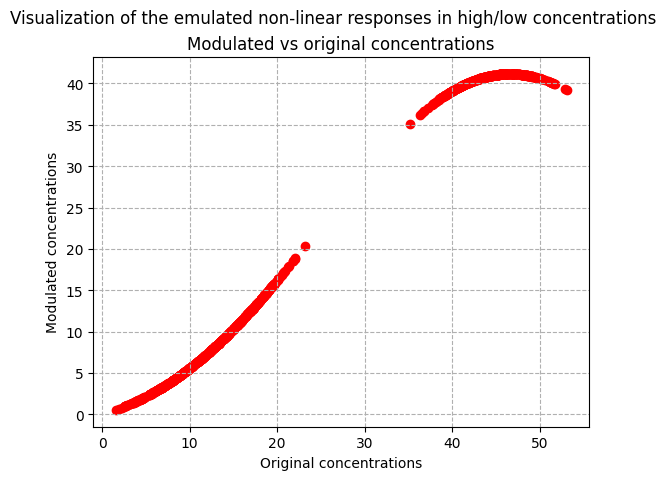

In [342]:
def modulate_y(y_target):
    """
    Modulates the reference concentrations to emulate the non-linear responses 
    in Raman signal to high/low concentrations by applying a gaussian enveloppe
    (arbitrary parameters).
    
    Args:
        y_target (1D array): Concentrations

    Returns:
        y_modulated (1D array): Modulated concentrations
    
    """
    y = np.asarray(y_target)
    y_norm = (y - y.min()) / (y.max() - y.min())  # normalize y to [0,1]
    center = 0.65
    coeffs = np.exp(-0.5 * ((y_norm - center) /0.45)**2)
    y_modulated = y*coeffs
    return(y_modulated)

plt.scatter(y, modulate_y(y), color = 'red')
plt.xlabel('Original concentrations')
plt.ylabel('Modulated concentrations')
plt.title('Modulated vs original concentrations')
plt.suptitle('Visualization of the emulated non-linear responses in high/low concentrations')
plt.grid(linestyle='--')
plt.show()


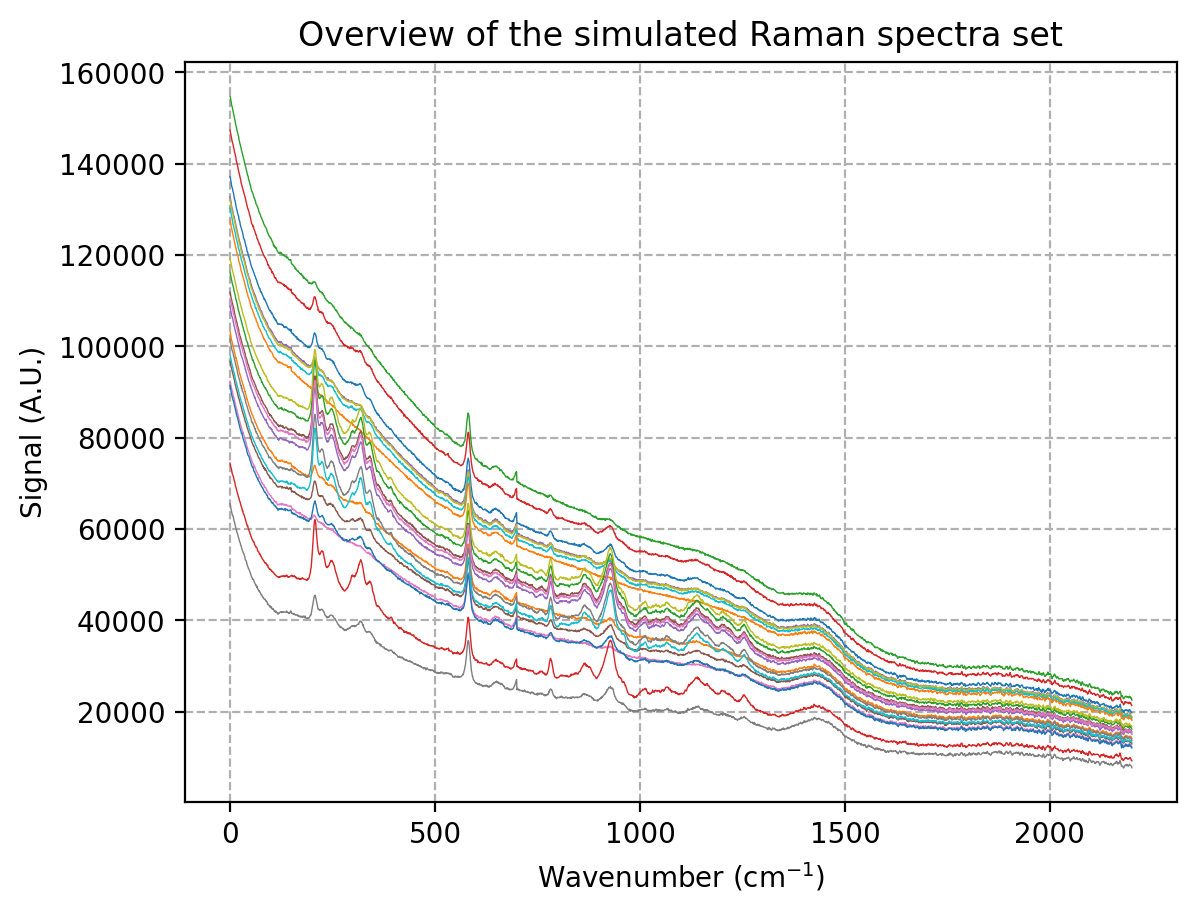

In [351]:
def generate_concentrations(n_samples):
    """
    Generates a set of analyte reference concentrations, between 5 and 50 g/L
    with 60% of concentrations in the 5-20 g/L range and 60% in the 
    40-50 g/L range.
    
    Args:
        n_samples (int): Number of samples

    Returns:
        y (1D array): Concentrations
    
    """
    
    np.random.seed(0)
    
    y = np.array([np.random.randint(5,20) for _ in range(int(0.6*n_samples))] + [np.random.randint(40,50) for _ in range(int(0.4*n_samples))])
    return(y)

def generate_spectra(original_spectrum, n_samples):
    """
    Generates a set of Raman spectra using the workflow described in "Synthetic data generation".
    
    Args:
        original_spectrum (1D array): Original experimental spectrum
        n_samples (int): Number of samples

    Returns:
        X (2D array): Set of spectra
        y (1D array): Concentrations
    
    """
    
    #Selecting raman bands that will be the footprint of the target analyte
    target_raman_band_1 = [x for x in range(150,500)]
    target_raman_band_2 = [x for x in range(700,1300)]

    #Generating the concentrations of the target analyte
    y = generate_concentrations(n_samples)

    #Introducing 2% of outliers by randomly selecting a subset of samples
    n_outliers = int(0.02*n_samples)
    outliers_index = np.random.randint(0,n_samples, n_outliers)

    #Modulating y to simulate non-linear responses
    y_modulated = modulate_y(y)

    #Introducing the outliers by replacing their corresponding y values by random values
    y_modulated[outliers_index] = np.random.randint(1,50)

    #Initializing spectra and baselines
    pure_spectra = np.ones((original_spectrum.shape[0], n_samples))
    baseline = np.zeros((original_spectrum.shape[0], n_samples))

    #Extracting baseline from a sampled experimental spectrum
    baseline_fitter = Baseline(x_data=[x for x in range(original_spectrum.shape[0])])
    background, params = baseline_fitter.asls(original_spectrum[:,0], lam=1e7, p=0.02)

    #Initializing the pure spectra as the original spectrum baseline corrected
    pure_spectra = pure_spectra * (original_spectrum - background.reshape(-1,1))

    #Multiplying the pure spectra by y on the target raman bands only with a smoothing factor
    width = 150
    scale = 0.05
    
    pure_spectra[target_raman_band_1, :] = pure_spectra[target_raman_band_1, :] * scale*(1 + (y_modulated-1) * np.exp(-0.5 * ((target_raman_band_1 - np.median(target_raman_band_1))/width)**2).reshape(-1,1))
    pure_spectra[target_raman_band_2, :] = pure_spectra[target_raman_band_2, :] * scale*(1+ (y_modulated-1) * np.exp(-0.5 * ((target_raman_band_2 - np.median(target_raman_band_2))/width)**2).reshape(-1,1))

    #Generating a random variation of the original baseline + noise for each spectrum
    baseline = baseline + background.reshape(-1,1) * np.random.normal(loc = 3, scale=0.9, size=(n_samples))
    noise = np.random.normal(loc = 0, scale=100, size=(original_spectrum.shape[0], n_samples))

    #Generating the spectra by summing the pure spectra, the baselines and the noise
    spectra = pure_spectra + baseline + noise
    X = spectra.T
    
    return(X, y)

n_samples = 1000
original_spectrum = pd.read_csv('original_spectrum.csv', index_col=0).values

X, y = generate_spectra(original_spectrum, n_samples) 
y = y + np.random.normal(loc = 0, scale = 1, size = (n_samples))

plt.figure(dpi=200)
for i in range(0,X.shape[0],50):
    plt.plot(X[i,:], lw=0.5)
plt.xlabel('Wavenumber (cm$^{-1}$)')
plt.ylabel('Signal (A.U.)')
plt.title('Overview of the simulated Raman spectra set')
plt.grid(linestyle=('--'))
plt.show()

### Spectroscopic parameters optimization

In [352]:
def baseline_correction(spectrum):
    """
    Extracts the baseline of a spectrum using the asymetric least squares (asls) algorithm
    then subtracts that baseline to the spectrum and return a baseline corrected spectrum

    Args:
        spectrum (1D array): Raman spectrum

    Returns:
        spectrum_corrected (1D array): Baseline corrected Raman spectrum
    
    """
    x = [x for x in range (spectrum.shape[0])]
    baseline_fitter = Baseline(x_data=x)
    
    bkg_2, params_2 = baseline_fitter.asls(spectrum, lam=1e7, p=0.02)
    spectrum_corrected = spectrum - bkg_2
    return(spectrum_corrected)

def snr(spectrum):
    """
    Computes the Signal to Noise Ratio (SNR) of a Raman spectrum by decomposing it in an approximation
    and 4 levels of details using wavelet transforms (Debauchy 4). The SNR is computed as the ratio between
    the maximum value of the approximation and 4 times the standard deviation of the lowest level of details
    containing only noise - in this case the 3rd level.
    
    Args:
        spectrum (1D array): Raman spectrum

    Returns:
        spectrum_corrected (float): SNR
    
    """
    wavelet = 'db4'
    coeffs = pywt.wavedec(spectrum, wavelet, level=4)
    noise = 4*np.std(coeffs[3]) #Detail level 3, where signal is purely noise
    signal = np.max(coeffs[0])

    snr = signal/noise
    
    return(snr)

# Models and benchmark

1. **Define models and hyperparameters**
   - Initialize:
     - **PLSRegression (PLSR)**: Tested with different numbers of latent variables (`n_components`).
     - **Support Vector Regression (SVR)**: Tested over a grid of `C` and `gamma` values with an RBF kernel.
   - Create three preprocessing strategies for the spectra:
     - **SNV (Standard Normal Variate)**
     - **Reduction**
     - **Centering**

2. **Evaluate PLSR across normalizations**
   - Split the dataset into training and testing subsets.
   - Use 5-fold cross-validation with `GridSearchCV` to optimize `n_components`.
   - Compute RMSE and R² on the test set.
   - Track the best normalization and parameters based on minimum RMSE.

3. **Evaluate SVR across normalizations**
   - Perform the same procedure, scanning over the SVR hyperparameter grid (`C`, `gamma`).
   - Identify the best normalization and parameter combination for SVR.

4. **Evaluate combined PLS-SVR model**
   - Use PLSR to reduce dimensionality of the spectra.
   - Transform both training and testing sets into the latent variable space.
   - Apply SVR on the transformed data with grid search.
   - Track the best combination of:
     - PLS latent variables
     - SVR hyperparameters
     - Normalization method

5. **Output results**
   - For each model (PLSR, SVR, PLS-SVR):
     - Print the best RMSE
     - Print the corresponding R² score
     - Display the optimal normalization strategy and hyperparameters.

6. **Create process and training subsets**
   - Randomly select 80% of the dataset as a "process" subset to simulate an ongoing chemical process.
   - The remaining 20% is used for training and model evaluation.
   - Reorder the process subset concentrations in descending order to mimic an analyte decreasing during the process.

7. **Run the benchmarking function**
   - Apply `benchmark_models()` on the training set to determine the best model configuration before applying it to the process subset.


In [353]:
from sklearn.cross_decomposition import PLSRegression #Version 1.7
from sklearn.svm import SVR #Version 1.7
from kennard_stone import train_test_split #Version 3.0
from sklearn.metrics import mean_squared_error, r2_score #Version 1.7
from sklearn.model_selection import GridSearchCV #Version 1.7
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning) #To disable warnings from Kennard Stone train_test_split which uses deprecated functions

In [370]:
def SNV(X):
    """
    Applies Standard Normal Variate (SNV) normalization to a dataset by centering and scaling each feature.

    Args:
        X (2D array): Input data matrix where rows are samples and columns are variables (e.g., spectral intensities).

    Returns:
        X_scaled (2D array): SNV-normalized data where each feature has zero mean and unit variance.
    """
    X_scaled = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
    return X_scaled


def reduction(X):
    """
    Applies variance reduction normalization to a dataset by scaling each feature by its standard deviation 
    without centering.

    Args:
        X (2D array): Input data matrix where rows are samples and columns are variables.

    Returns:
        X_scaled (2D array): Variance-reduced data where each feature is scaled by its standard deviation.
    """
    X_scaled = X / np.std(X, axis=0)
    return X_scaled


def centering(X):
    """
    Applies mean-centering to a dataset by subtracting the mean of each feature.

    Args:
        X (2D array): Input data matrix where rows are samples and columns are variables.

    Returns:
        X_scaled (2D array): Mean-centered data where each feature has zero mean.
    """
    X_scaled = (X - np.mean(X, axis=0))
    return X_scaled

In [481]:
def benchmark_models(X,y):
    """
    Benchmarks three regression approaches (PLS, SVR, and a hybrid PLS-SVR) for predicting target values from 
    spectral data using different normalization techniques and hyperparameter optimization.

    The function:
    - Applies three preprocessing methods (SNV, variance reduction, mean centering).
    - Performs grid search with cross-validation to tune hyperparameters for each model.
    - Evaluates models based on RMSE and R² on a held-out test set.
    - Compares the performance of:
        * PLS regression
        * Support Vector Regression (SVR)
        * A two-step hybrid model using PLS for dimensionality reduction followed by SVR.

    Args:
        X (2D array, shape (n_samples, n_features)): Input spectral dataset where rows are samples and columns are variables.
        y (1D array, shape (n_samples,)): Target concentrations associated with each spectrum.

    Returns:
        None: Prints the best RMSE, optimal hyperparameters, and normalization method for each model.
    """
    
    plsr = PLSRegression()
    svr = SVR()
    
    # Define hyperparameter grid
    param_grid_pls = {
        'n_components': [n for n in range(2,17)]
    }
    
    param_grid_svr = {
        'kernel': ['rbf'],
        'C': [1, 5, 10, 50, 100, 500, 1000, 5000, 10_000],
        'gamma': [1e-5,1e-4,1e-3,1e-2,1e-1,1]
    }
    
    datasets = [SNV(X), reduction(X), centering(X)]
    normalization = ['SNV', 'Reduction', 'Centering']
    
    best_rmse = np.inf
    c= 0
    for X_scaled in datasets:
        X_train, X_test, y_train, y_test = train_test_split(X_scaled,y, test_size = 0.3, n_jobs = -1)
        pls_gs = GridSearchCV(plsr, param_grid_pls, scoring='neg_root_mean_squared_error',cv=5, n_jobs=-1)
        pls_gs.fit(X_train, y_train)
        y_pred = pls_gs.best_estimator_.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        if rmse<best_rmse:
            best_norm = normalization[c]
            best_rmse = rmse
            best_parameters = pls_gs.best_params_
            best_r2 = r2_score(y_pred, y_test)
        c+=1
    
    print(f'PLS - Best RMSE: {best_rmse}')
    print(f'Best parameters: {best_parameters}')
    print(f'Best normalization: {best_norm}')
    print(f'Best R²: {best_r2}')
    print('---------------------------------------')
    
    
    best_rmse = np.inf
    c= 0
    for X_scaled in datasets:
        X_train, X_test, y_train, y_test = train_test_split(X_scaled,y, test_size = 0.3, n_jobs = -1)
        svr_gs = GridSearchCV(svr, param_grid_svr, scoring='neg_root_mean_squared_error',cv=5, n_jobs=-1)
        svr_gs.fit(X_train, y_train)
        y_pred = svr_gs.best_estimator_.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        if rmse<best_rmse:
            best_norm =  normalization[c]
            best_rmse = rmse
            best_parameters = svr_gs.best_params_
            best_r2 = r2_score(y_pred, y_test)
        c+=1
    
    print(f'SVR - Best RMSE: {best_rmse}')
    print(f'Best parameters: {best_parameters}')
    print(f'Best normalization: {best_norm}')
    print(f'Best R²: {best_r2}')
    print('---------------------------------------')
    
    best_rmse = np.inf
    c= 0
    for X_scaled in datasets:
        X_train, X_test, y_train, y_test = train_test_split(X_scaled,y, test_size = 0.3, n_jobs = -1)
        pls_gs = GridSearchCV(plsr, param_grid_pls, scoring='neg_root_mean_squared_error',cv=5, n_jobs=-1)
        pls_gs.fit(X_train, y_train)
    
        X_train_transform, X_test_transform = pls_gs.best_estimator_.transform(X_train), pls_gs.best_estimator_.transform(X_test)
        
        pls_svr_gs = GridSearchCV(svr, param_grid_svr, scoring='neg_root_mean_squared_error',cv=5, n_jobs=-1)
        pls_svr_gs.fit(X_train_transform, y_train)
        y_pred = pls_svr_gs.best_estimator_.predict(X_test_transform)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        if rmse<best_rmse:
            best_norm =  normalization[c]
            best_rmse = rmse
            best_parameters = pls_svr_gs.best_params_, pls_gs.best_params_
            best_r2 = r2_score(y_pred, y_test)
        c+=1
    
    print(f'PLS- SVR - Best RMSE: {best_rmse}')
    print(f'Best parameters: {best_parameters}')
    print(f'Best normalization: {best_norm}')
    print(f'Best R²: {best_r2}')

    return()

#Split the samples in training samples and process samples
#The process samples emulate the production samples on which the model is applied
process_samples = np.random.randint(0, X.shape[0], int(0.8*n_samples))
training_samples = [x for x in range(X.shape[0]) if x not in process_samples]


X_process = X[process_samples]
X_training = X[training_samples]
y_process = y[process_samples]
y_training = y[training_samples]

#Sort by decreasing values of y the process samples to emulate the evolution of the analyte concentrations during the process
ordered_process_idx = np.argsort(-y_process)
X_process = X_process[ordered_process_idx]
y_process = y_process[ordered_process_idx]

benchmark_models(X_training, y_training)

PLS - Best RMSE: 3.080671310796188
Best parameters: {'n_components': 2}
Best normalization: Reduction
Best R²: 0.9571467585217968
---------------------------------------
SVR - Best RMSE: 2.6971111225545132
Best parameters: {'C': 1000, 'gamma': 0.01, 'kernel': 'rbf'}
Best normalization: Reduction
Best R²: 0.9741200325052021
---------------------------------------
PLS- SVR - Best RMSE: 2.569270973936665
Best parameters: ({'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}, {'n_components': 2})
Best normalization: Centering
Best R²: 0.9761537457613207


()

### Modeling

This step builds a **PLS-SVR pipeline** to predict concentrations from the spectral data:

1. **Normalization:** Tests three preprocessing methods (SNV, variance reduction, centering).
2. **Dimensionality Reduction:** Uses `PLSRegression` to extract latent variables.
3. **Non-linear Regression:** Fits an `SVR` on the PLS-transformed space.
4. **Model Selection:** Performs grid search with cross-validation to find the best combination of PLS components, SVR hyperparameters, and normalization based on RMSE.
5. **Evaluation:** Applies the optimal pipeline to training data and plots predicted vs. reference concentrations.


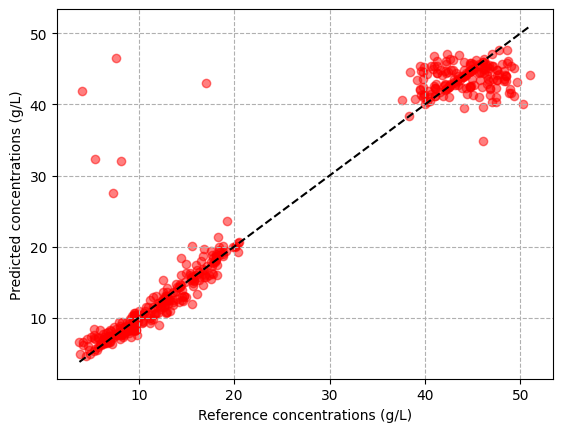

In [369]:
def model(X, y):
    plsr = PLSRegression()
    svr = SVR()
    
    # Define hyperparameter grid
    param_grid_pls = {
        'n_components': [n for n in range(2,17)]
    }
    
    param_grid_svr = {
        'kernel': ['rbf'],
        'C': [1, 5, 10, 50, 100, 500, 1000, 5000, 10_000],
        'gamma': [1e-5,1e-4,1e-3,1e-2,1e-1,1]
    }
    
    datasets = [SNV(X), reduction(X), centering(X)]
    normalization = ['SNV', 'Reduction', 'Centering']
    best_rmse = np.inf
    c= 0
    for X_scaled in datasets:
        X_train, X_test, y_train, y_test = train_test_split(X_scaled,y, test_size = 0.3, n_jobs = -1)
        pls_gs = GridSearchCV(plsr, param_grid_pls, scoring='neg_root_mean_squared_error',cv=5, n_jobs=-1)
        pls_gs.fit(X_train, y_train)
    
        X_train_transform, X_test_transform = pls_gs.best_estimator_.transform(X_train), pls_gs.best_estimator_.transform(X_test)
        
        pls_svr_gs = GridSearchCV(svr, param_grid_svr, scoring='neg_root_mean_squared_error',cv=5, n_jobs=-1)
        pls_svr_gs.fit(X_train_transform, y_train)
        y_pred = pls_svr_gs.best_estimator_.predict(X_test_transform)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        if rmse<best_rmse:
            best_norm =  normalization[c]
            best_rmse = rmse

        c+=1
    return(pls_gs.best_estimator_, pls_svr_gs.best_estimator_, best_norm)

pls, svr, norm = model(X_training, y_training)

datasets = [SNV(X_training), reduction(X_training), centering(X_training)]
normalization = ['SNV', 'Reduction', 'Centering']
X_scaled = datasets[normalization.index(norm)]

plt.scatter(y_training , svr.predict(pls.transform(X_scaled)), color = 'red', alpha=0.5)
plt.plot([np.min(y_training), np.max(y_training)], [np.min(y_training), np.max(y_training)], linestyle = '--', color = 'black')
plt.xlabel('Reference concentrations (g/L)')
plt.ylabel('Predicted concentrations (g/L)')
plt.grid(linestyle=('--'))
plt.show()

### Process monitoring

1. Applies the previously trained **PLS-SVR model** and selected normalization to new process spectral data.
2.  Predicts analyte concentrations along the process timeline.
3.  Visualizes predicted concentrations versus reference values at selected time points to assess model performance during monitoring.


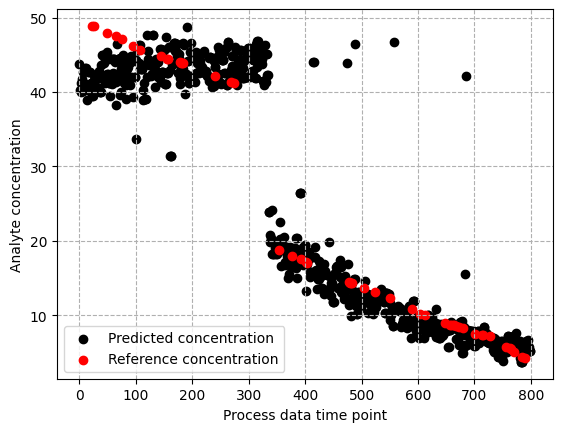

In [362]:
def monitoring(X, y, pls, svr, norm):
    """
    Predicts analyte concentrations for synthetic process data using a calibrated PLS-SVR model.

    The input dataset is scaled according to the specified normalization method, 
    transformed by the PLS model, and passed to the SVR for prediction.

    Args:
        X (2D array): Input feature matrix for process samples.
        y (1D array): Reference concentrations (not used in prediction, kept for consistency).
        pls (PLSRegression object): Trained Partial Least Squares model.
        svr (SVR object): Trained Support Vector Regression model.
        norm (str): Normalization method used during training ('SNV', 'Reduction', or 'Centering').

    Returns:
        y_pred (1D array): Predicted analyte concentrations for the process samples.
    """
    
    datasets = [SNV(X), reduction(X), centering(X)]
    normalization = ['SNV', 'Reduction', 'Centering']
    X_scaled = datasets[normalization.index(norm)]

    y_pred = svr.predict(pls.transform(X_scaled))

    return(y_pred)

process_ref_idx = np.random.randint(0,len(y_process), 50)
plt.scatter([x for x in range(len(y_process))], monitoring(X_process, y_process, pls, svr, norm), color = 'black', label= 'Predicted concentration')
plt.scatter(process_ref_idx, y_process[process_ref_idx], color = 'red', label='Reference concentration')
plt.xlabel('Process data time point')
plt.ylabel('Analyte concentration')
plt.grid(linestyle=('--'))
plt.legend()
plt.show()

### Learning curve

This analysis evaluates the robustness of the PLS-SVR model as the number of available observations decreases.  

**Workflow:**

1. **Subsampling & Retraining:**  
   Samples are randomly removed in multiple repetitions. After each removal, the dataset is centered, split, and the PLS-SVR model retrained.  
   The RMSEP is recorded at each step.

2. **Aggregating Results:**  
   The RMSEP scores are averaged across repetitions to compute the mean learning curve. A 95% confidence interval is calculated using the Student's t-distribution.

3. **Exponential Fit & Saturation Point:**  
   An exponential decay function is fitted to the mean RMSEP values.  
   The point where the curve flattens (saturation point) is identified to estimate the minimum number of samples needed for stable model performance.

4. **Output:**  
   - **Mean RMSEP curve** (red) showing performance degradation as samples decrease.  
   - **95% confidence interval** (shaded region) quantifying uncertainty.  
   - **Exponential fit** (blue dashed line) modeling the trend.  
   - **Saturation point** (purple cross) highlighting where adding more data yields minimal benefit.

The resulting plot provides both an estimate of model stability and guidance on the optimal dataset size for training.



In [336]:
from tqdm import tqdm
import scipy

In [401]:
def generate_learning_curve(X,y, pls, svr, repetitions=15):
    """
    Generates a learning curve for the PLS-SVR model by iteratively reducing the dataset size 
    and measuring the impact on prediction error.

    For each repetition, samples are randomly removed one by one until only 20 remain.
    After each removal, the model is retrained on the reduced dataset and the RMSEP is computed.

    Args:
        X (2D array): Input feature matrix.
        y (1D array): Target variable vector.
        pls (PLSRegression object): Pre-initialized Partial Least Squares model.
        svr (SVR object): Pre-initialized Support Vector Regression model.
        repetitions (int, optional): Number of repetitions for random subsampling. Default is 15.

    Returns:
        score (2D array): Matrix of RMSEP values with shape (repetitions, number of deletions).
    """
    
    score = np.zeros((repetitions,X.shape[0]-20))
    for repetition in tqdm(range(repetitions)):
        
        X_copy = X.copy()
        y_copy = y.copy()
        
        for deletion in range(X.shape[0]-20):
            #Select a random sample in X and delete it in X and y
            del_idx = np.random.randint(0,X_copy.shape[0])
            X_copy = np.delete(X_copy, del_idx, axis=0)
            y_copy = np.delete(y_copy, del_idx, axis=0)

            #Normalizing X
            X_scaled = centering(X_copy)

            #Train test split
            X_train, X_test, y_train, y_test = train_test_split(X_scaled,y_copy, test_size = 0.3, n_jobs = -1)

            #Training of the PLS model
            pls.fit(X_train, y_train)

            #Projection of X_train and X_test in the latent space
            X_train_transform, X_test_transform = pls.transform(X_train), pls.transform(X_test)

            #Training of the SVR on the projected X_train_transform and y_train
            svr.fit(X_train_transform, y_train)

            #Prediction using X_test_transform
            y_pred = svr.predict(X_test_transform)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))

            #Registering the rmse in the score matrix
            score[repetition, deletion] = rmse
    
    return(score)

In [479]:
def display_learning_curve(learning_curve_scores):
    """
    Displays the learning curve with confidence intervals and fits an exponential function 
    to identify the saturation point of the PLS-SVR model.

    The function computes the mean RMSEP and 95% confidence interval across repetitions,
    fits an exponential decay to the mean curve, and identifies the point where 
    adding more samples yields minimal improvement.

    Args:
        learning_curve_scores (2D array): Matrix of RMSEP values generated by generate_learning_curve().

    Returns:
        None: Displays the learning curve plot with:
            - Mean RMSEP curve (red)
            - 95% confidence interval (shaded)
            - Exponential fit (blue dashed)
            - Saturation point (purple cross)
    """
    scoring = pd.DataFrame(learning_curve_scores.T)
    
    mean = scoring.mean(axis=1)
    stddev = scoring.std(axis=1)
    
    
    confidence = 0.95
    n = scoring.shape[1]
    t_value = scipy.stats.t.ppf((1 + confidence) / 2.0, df=n - 1)
    margin_of_error = t_value * (stddev / np.sqrt(n))
    ci_lower = mean - margin_of_error
    ci_upper = mean + margin_of_error
    
    x = [X_training.shape[0] - x for x in scoring.index]
    
    def exponential_func(x, a, b, c):
        return a * np.exp(-b * np.array(x)) + c
    
    popt, pcov = scipy.optimize.curve_fit(exponential_func, x[50:], mean[50:])
    a, b, c = popt
    
    # Find the point where the curve starts to become flat
    threshold = 0.001  # Adjust this value as needed
    flat_point = np.argmin(np.abs(np.diff(exponential_func(x, a, b, c))) < threshold)
    flat_x = int(x[flat_point])
    flat_y = exponential_func(flat_x, a, b, c)
    
    plt.plot(x, mean, color='red', label='Mean RMSEP')
    
    plt.plot(x, exponential_func(x, a, b, c), color='blue', label='Exponential Fit', linestyle='--')
    
    plt.scatter(flat_x, flat_y, color='purple', marker='x', s=200, label='Saturation Point')
    
    plt.fill_between(x, ci_lower, ci_upper, color='red', alpha=0.2, lw=0.5, linestyle='--', label='Confidence Interval (95%)')
    
    plt.xlabel('Number of observations')
    
    
    plt.ylabel('RMSEP (g/L)')

    plt.legend()
    plt.grid(linestyle='--', linewidth=0.5)
    
    plt.xticks([point for point in range(20,np.max(x),50)])  # Set the x-axis lower limit to 0, upper limit is automatic
    plt.ylim(0, None)

    plt.title('Learning curve')
    
    plt.tight_layout()
    plt.show()

    return()

100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [10:17<00:00, 41.14s/it]


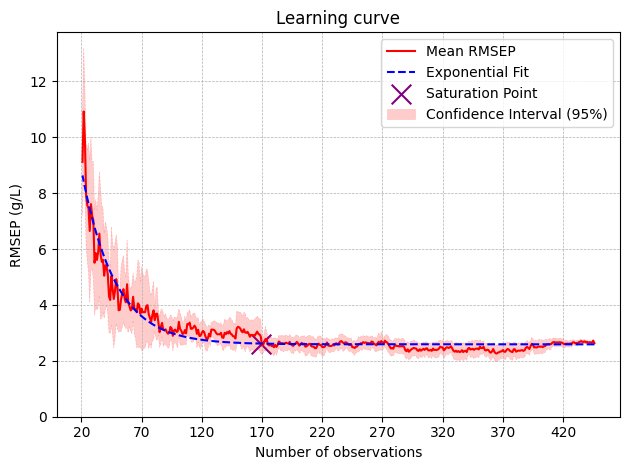

()

In [480]:
warnings.simplefilter(action='ignore', category=RuntimeWarning) #Ignore Runtime warning of the exponential curve fitting
score = generate_learning_curve(X_training, y_training, pls, svr)
display_learning_curve(score)